In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# add code directory to path
import sys
import os
sys.path.append(os.path.join(os.path.abspath(''), 'code'))

In [3]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

In [4]:
from config import load_config

In [5]:
config = load_config("configs/config_hammer.yaml", verbose=False)
sequences_df = pd.read_csv(config["dataset_path"])
sequences_df["log_fold_improvement"] = np.log2(sequences_df["fold_improvement"])
wt_seq = sequences_df.loc[0]

In [6]:
from utils import get_columns_between

In [7]:
designed_positions_df = get_columns_between(sequences_df, config["first_column_name"], config["last_column_name"])
designed_positions_df

,Y20,Y24,E34,I37,D167,Y176,D197,A198,L199,S201,Y204,S213,Y242,A247,N248,N249,L252,F253
0,Y,Y,E,I,D,Y,D,A,L,S,Y,S,Y,A,N,N,L,F
1,H,Y,E,I,C,Y,D,M,L,A,Y,A,Y,A,N,N,L,F
2,Y,Y,E,I,H,Y,D,M,L,C,Y,A,Y,A,N,C,L,F
3,Y,Y,E,I,H,Y,D,S,L,R,Y,S,W,A,N,S,L,F
4,F,Y,E,I,H,Y,D,M,L,C,Y,C,Y,A,N,N,L,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233,Y,Y,E,W,H,F,D,M,L,C,Y,C,H,C,N,A,M,Y
234,Y,Y,E,W,H,F,D,V,L,C,Y,T,M,A,N,A,H,Y
235,Y,Y,E,W,H,F,D,A,L,C,Y,S,H,A,N,T,L,F
236,Y,Y,E,W,H,F,D,M,L,C,Y,V,F,A,N,A,Y,Y


In [8]:
from epinnet import mutation_predictability

In [9]:
from bootstrap import get_oh_table

In [10]:
oh_funclib_df, y, design_numbers = get_oh_table(
    config["dataset_path"],
    first_col=config["first_column_name"],
    last_col=config["last_column_name"],
    y_col="fold_improvement"
)
# oh_funclib_df = oh_funclib_df.iloc[1:]
# experimental_results_df = pd.read_csv(f"{config["data_dir_path"]}/experimental_results.csv")
# y = experimental_results_df["malathion"]
# shift y index such that it starts from 1
# y.index = range(1, len(y) + 1)
log_y = np.log(y + 1e-8)  # avoid log(0)

In [11]:
pairwise_similarities = oh_funclib_df.astype(int) @ oh_funclib_df.astype(int).T
# subtract from value at diagonal to get differences
pairwise_differences = np.ones_like(pairwise_similarities) * pairwise_similarities.loc[0][0] - pairwise_similarities
wt_distances = pairwise_differences.loc[0]
min_distance_from_wt = wt_distances.min()
max_distance_from_wt = wt_distances.max()

pairs = {}

for i in range(min_distance_from_wt, max_distance_from_wt + 1):
    # ignore wt itself
    if i == 0:
        continue
    for j in range(i + 1, max_distance_from_wt + 1):
        print(f"Checking pairs with distances {i} and {j} from WT...")
        # find pairs where the distance between them is j - i
        i_from_wt = wt_distances[wt_distances == i].index
        j_from_wt = wt_distances[wt_distances == j].index
        for idx_i in i_from_wt:
            for idx_j in j_from_wt:
                if pairwise_differences.loc[idx_i, idx_j] == j - i:
                    pairs[(idx_i, idx_j)] = (i, j)
                    print(f"Found pair: {idx_i} and {idx_j} with distance {j - i}")

Checking pairs with distances 1 and 2 from WT...
Checking pairs with distances 1 and 3 from WT...
Checking pairs with distances 1 and 4 from WT...
Checking pairs with distances 1 and 5 from WT...
Checking pairs with distances 1 and 6 from WT...
Checking pairs with distances 1 and 7 from WT...
Checking pairs with distances 1 and 8 from WT...
Checking pairs with distances 1 and 9 from WT...
Checking pairs with distances 1 and 10 from WT...
Checking pairs with distances 1 and 11 from WT...
Checking pairs with distances 2 and 3 from WT...
Checking pairs with distances 2 and 4 from WT...
Checking pairs with distances 2 and 5 from WT...
Checking pairs with distances 2 and 6 from WT...
Checking pairs with distances 2 and 7 from WT...
Checking pairs with distances 2 and 8 from WT...
Checking pairs with distances 2 and 9 from WT...
Checking pairs with distances 2 and 10 from WT...
Checking pairs with distances 2 and 11 from WT...
Checking pairs with distances 3 and 4 from WT...
Checking pairs w

In [12]:
mses, spearman_corrs, muts = [], [], []
for col in oh_funclib_df.columns:
    # if col[0] == col[-1]: # Skip wt
        # continue
    mut_mse, spearman_corr = mutation_predictability(oh_funclib_df, col, log_y)
    mses.append(mut_mse)
    muts.append(col)
    spearman_corrs.append(spearman_corr)

mses = np.array(mses)
spearman_corrs = np.array(spearman_corrs)
# replace nan values in spearman_corrs with 0
spearman_corrs = np.nan_to_num(spearman_corrs, nan=0.0)

/home/labs/fleishman/omripo/Projects/adaptive_learning/code/epinnet.py:51: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_corr, _ = spearmanr(y[mut_df.index], mut_pred)


In [13]:
variant_predictability = oh_funclib_df.values @ spearman_corrs

In [14]:
# create a graph where each node is a variant, and edges connect those that are one mutation apart
import networkx as nx
diffs = []
G = nx.DiGraph()
for i, row in sequences_df.iterrows():
    G.add_node(row["design"], fold_improvement=row["fold_improvement"], predictability=variant_predictability[i],
               log_fold_improvement=row["log_fold_improvement"], diff_from_WT=wt_distances[i])
for i, row1 in sequences_df.iterrows():
    for j, row2 in sequences_df.iterrows():
        if i < j:  # avoid double counting
            designed_pos_1 = designed_positions_df.iloc[i]
            designed_pos_2 = designed_positions_df.iloc[j]
            diff = sum(1 for a, b in zip(designed_pos_1, designed_pos_2) if a != b)
            diffs.append(diff)
            
            if pairs.get((i, j)):
                G.add_edge(row1["design"], row2["design"], diff=diff)
                print(f"Added edge between {row1['design']} and {row2['design']} with diff {diff}")
            elif pairs.get((j, i)):
                G.add_edge(row2["design"], row1["design"], diff=diff)
                print(f"Added edge between {row2['design']} and {row1['design']} with diff {diff}")

# remove isolated nodes
G.remove_nodes_from(list(nx.isolates(G)))

# remove subgraphs with less than n nodes
for subgraph in list(nx.weakly_connected_components(G)):
    if len(subgraph) < 6:
        G.remove_nodes_from(subgraph)

Added edge between FL1_31 and FL2-2_01 with diff 5
Added edge between FL1_31 and FL2-2_02 with diff 3
Added edge between FL1_31 and FL2-2_03 with diff 5
Added edge between FL1_31 and FL2-2_04 with diff 4
Added edge between FL1_31 and FL2-2_05 with diff 3
Added edge between FL1_31 and FL2-2_06 with diff 5
Added edge between FL1_31 and FL2-2_07 with diff 4
Added edge between FL1_31 and FL2-2_08 with diff 5
Added edge between FL1_31 and FL2-2_09 with diff 4
Added edge between FL1_31 and FL2-2_10 with diff 4
Added edge between FL1_31 and FL2-2_11 with diff 5
Added edge between FL1_31 and FL2-2_12 with diff 4
Added edge between FL1_31 and FL2-2_13 with diff 4
Added edge between FL1_31 and FL2-2_14 with diff 4
Added edge between FL1_31 and FL2-2_15 with diff 5
Added edge between FL1_31 and FL2-2_16 with diff 4
Added edge between FL1_31 and FL2-2_17 with diff 4
Added edge between FL1_31 and FL2-2_18 with diff 5
Added edge between FL1_31 and FL2-2_19 with diff 3
Added edge between FL1_31 and F

In [15]:
from pyvis.network import Network

[autoreload of epinnet failed: Traceback (most recent call last):
  File "/home/labs/fleishman/omripo/Projects/adaptive_learning/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/home/labs/fleishman/omripo/Projects/adaptive_learning/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/home/labs/fleishman/omripo/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/importlib/__init__.py", line 131, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 995, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1133, in get_code
  File "<frozen importlib._bootstrap_external>", line 1063, in source_to_code
  File "<frozen importlib._bootstrap>", line 488, in _

In [16]:
# interactive plot of the graph
cmap = plt.get_cmap("viridis")

def get_color(value, min_val, max_val, cmap):
    """Map a numeric value to a color in the selected colormap."""
    if max_val == min_val:
        return "rgba(200, 200, 200, 1)"
    normalized = (value - min_val) / (max_val - min_val)
    rgba = cmap(normalized)
    return mcolors.rgb2hex(rgba)

def build_colorbar_html(min_val, max_val, cmap, label, steps=12):
    gradient_stops = []
    for idx, value in enumerate(np.linspace(0, 1, steps)):
        color = mcolors.rgb2hex(cmap(value))
        gradient_stops.append(f"{color} {idx / (steps - 1) * 100:.1f}%")

    gradient_css = ", ".join(gradient_stops)
    mid_val = (min_val + max_val) / 2

    return f"""
<style>
#colorbar-container {{
    position: fixed;
    top: 24px;
    right: 24px;
    z-index: 9999;
    display: flex;
    gap: 12px;
    align-items: stretch;
    padding: 14px 16px;
    border-radius: 12px;
    background: rgba(255, 255, 255, 0.92);
    border: 1px solid rgba(0, 0, 0, 0.08);
    box-shadow: 0 8px 24px rgba(0, 0, 0, 0.18);
    font-family: Arial, sans-serif;
    color: #1f2937;
}}

#colorbar-title {{
    margin: 0 0 8px 0;
    font-size: 14px;
    font-weight: 700;
}}

#colorbar-bar {{
    width: 20px;
    height: 220px;
    border-radius: 999px;
    border: 1px solid rgba(0, 0, 0, 0.12);
    background: linear-gradient(to top, {gradient_css});
}}

#colorbar-scale {{
    display: flex;
    gap: 10px;
    align-items: stretch;
}}

#colorbar-labels {{
    height: 220px;
    display: flex;
    flex-direction: column;
    justify-content: space-between;
    font-size: 12px;
}}
</style>

<div id=\"colorbar-container\">
    <div>
        <div id=\"colorbar-title\">{label}</div>
        <div id=\"colorbar-scale\">
            <div id=\"colorbar-bar\"></div>
            <div id=\"colorbar-labels\">
                <span>{max_val:.2f}</span>
                <span>{mid_val:.2f}</span>
                <span>{min_val:.2f}</span>
            </div>
        </div>
    </div>
</div>
"""

def add_colorbar_to_html(html_path, min_val, max_val, cmap, label):
    start_marker = "<!-- COLORBAR_START -->"
    end_marker = "<!-- COLORBAR_END -->"
    colorbar_block = (
        f"{start_marker}\n"
        f"{build_colorbar_html(min_val, max_val, cmap, label)}\n"
        f"{end_marker}"
    )

    with open(html_path, "r", encoding="utf-8") as file:
        html = file.read()

    if start_marker in html and end_marker in html:
        start_idx = html.index(start_marker)
        end_idx = html.index(end_marker) + len(end_marker)
        html = html[:start_idx] + colorbar_block + html[end_idx:]
    else:
        html = html.replace("</body>", f"{colorbar_block}\n</body>")

    with open(html_path, "w", encoding="utf-8") as file:
        file.write(html)

# Before your loop, get the bounds
all_pred = [G.nodes[n]['predictability'] for n in G.nodes()]
all_log_fold_improvement = [G.nodes[n]['log_fold_improvement'] for n in G.nodes()]
min_p, max_p = min(all_pred), max(all_pred)
min_f, max_f = min(all_log_fold_improvement), max(all_log_fold_improvement)

net = Network(notebook=True, height="100vh", width="100%", cdn_resources="in_line")

for node, degree in zip(G.nodes(data=True), G.degree()):
    p_val = node[1]['predictability']
    log_fold_improvement = node[1]['log_fold_improvement']
    # node_color = get_color(p_val, min_p, max_p, cmap)
    node_color = get_color(log_fold_improvement, min_f, max_f, cmap)

    net.add_node(
        node[0],
        label=str(node[0]),
        title=f"Predictability: {p_val:.2f}, Fold Improvement: {node[1]['fold_improvement']:.2f}",
        color=node_color,
        size=node[1]['fold_improvement'] / 50,
    )
for edge in G.edges(data=True):
    net.add_edge(edge[0], edge[1], title=f"Diff: {edge[2]['diff']}", value=edge[2]['diff'], weight=edge[2]['diff'])
# net.force_atlas_2based()
# net.toggle_physics(False)
html_path = "variant_graph.html"
net.show(html_path)
net.save_graph(html_path)
add_colorbar_to_html(html_path, min_f, max_f, cmap, "log2 fold improvement")

[autoreload of epinnet failed: Traceback (most recent call last):
  File "/home/labs/fleishman/omripo/Projects/adaptive_learning/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/home/labs/fleishman/omripo/Projects/adaptive_learning/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/home/labs/fleishman/omripo/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/importlib/__init__.py", line 131, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 995, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1133, in get_code
  File "<frozen importlib._bootstrap_external>", line 1063, in source_to_code
  File "<frozen importlib._bootstrap>", line 488, in _

variant_graph.html


In [17]:
min_dist_in_graph = min([data['diff_from_WT'] for _, data in G.nodes(data=True)])
# BFS from lowest number of mutations to highest and save paths
min_nodes = [node for node, data in G.nodes(data=True) if data['diff_from_WT'] == min_dist_in_graph]


In [18]:
paths = []
for start in min_nodes:
    visited = set()
    queue = [(start, [start])]
    while queue:
        visited_temp = set()
        temp_queue = []
        for current, path in queue:
            visited_temp.add(current)
            # if current has no neighbors, save the path
            if len(list(G.neighbors(current))) == 0:
                paths.append(path)
                continue

            for neighbor in G.neighbors(current):
                if neighbor not in visited:
                    temp_queue.append((neighbor, path + [neighbor]))
        queue = temp_queue
    visited.update(visited_temp)
        


In [19]:
# remove paths of length 2, and break paths longer than 3 into subpaths of length 3
len_3_paths = []
for path in paths:
    if len(path) < 3:
        continue
    elif len(path) == 3:
        len_3_paths.append(path)
    else:
        for i in range(len(path) - 2):
            len_3_paths.append(path[i:i+3])

In [20]:
from enum import Enum
class PathType(Enum):
    POSITIVE_EPIS = "positive_epis"
    NEGATIVE_EPIS = "negative_epis"
    POSITIVE_SIGN_EPIS = "positive_sign_epis"
    NEGATIVE_SIGN_EPIS = "negative_sign_epis"
    ADDITIVE = "additive"
    NEGATIVE = "negative"

In [21]:
paths_dict = {
    t: [] for t in PathType
}

path_types = list(paths_dict.keys())

ratio_threshold = 3
inverse_ratio_threshold = 1 / ratio_threshold

for node1, node2, node3 in len_3_paths:
    fold1 = G.nodes[node1]['fold_improvement']
    fold2 = G.nodes[node2]['fold_improvement']
    fold3 = G.nodes[node3]['fold_improvement']
    
    first_ratio = fold2 / fold1
    second_ratio = fold3 / fold2
    third_ratio = fold3 / fold1

    if fold3 >= fold2 >= fold1:
        if first_ratio > ratio_threshold or second_ratio > ratio_threshold:
            paths_dict[PathType.POSITIVE_EPIS].append((node1, node2, node3))
            G.edges[node1, node2]['path_type'] = PathType.POSITIVE_EPIS
            G.edges[node2, node3]['path_type'] = PathType.POSITIVE_EPIS
        else:
            paths_dict[PathType.ADDITIVE].append((node1, node2, node3))
            G.edges[node1, node2]['path_type'] = PathType.ADDITIVE
            G.edges[node2, node3]['path_type'] = PathType.ADDITIVE
    elif fold3 <= fold2 <= fold1:
        paths_dict[PathType.NEGATIVE_EPIS].append((node1, node2, node3))
        G.edges[node1, node2]['path_type'] = PathType.NEGATIVE_EPIS
        G.edges[node2, node3]['path_type'] = PathType.NEGATIVE_EPIS
    elif fold1 >= fold2 and fold2 <= fold3:
        if first_ratio < inverse_ratio_threshold and second_ratio > ratio_threshold:
            paths_dict[PathType.POSITIVE_SIGN_EPIS].append((node1, node2, node3))
            G.edges[node1, node2]['path_type'] = PathType.POSITIVE_SIGN_EPIS
            G.edges[node2, node3]['path_type'] = PathType.POSITIVE_SIGN_EPIS
    elif fold1 <= fold2 and fold2 >= fold3:
        if first_ratio > ratio_threshold and second_ratio < inverse_ratio_threshold:
            paths_dict[PathType.NEGATIVE_SIGN_EPIS].append((node1, node2, node3))
            G.edges[node1, node2]['path_type'] = PathType.NEGATIVE_SIGN_EPIS
            G.edges[node2, node3]['path_type'] = PathType.NEGATIVE_SIGN_EPIS
    elif third_ratio > ratio_threshold:
        paths_dict[PathType.POSITIVE_EPIS].append((node1, node2, node3))
        G.edges[node1, node2]['path_type'] = PathType.POSITIVE_EPIS
        G.edges[node2, node3]['path_type'] = PathType.POSITIVE_EPIS


In [22]:
print(f"Positive paths: {len(paths_dict[PathType.POSITIVE_EPIS])}")
print(f"Additive paths: {len(paths_dict[PathType.ADDITIVE])}")
print(f"Negative paths: {len(paths_dict[PathType.NEGATIVE_EPIS])}")
print(f"Positive sign epistasis paths: {len(paths_dict[PathType.POSITIVE_SIGN_EPIS])}")
print(f"Negative sign epistasis paths: {len(paths_dict[PathType.NEGATIVE_SIGN_EPIS])}")

Positive paths: 0
Additive paths: 3
Negative paths: 6
Positive sign epistasis paths: 2
Negative sign epistasis paths: 1


In [23]:
type_cmap = plt.get_cmap("tab10", len(path_types))
path_type_colors = {path_type: type_cmap(index) for index, path_type in enumerate(path_types)}

interesting_paths = []
interesting_triples = set()
edge_type_lookup = {}

for path in paths:
    if len(path) < 3:
        continue
    for i in range(len(path) - 1):
        node1 = path[i]
        node2 = path[i + 1]
        ratio = G.nodes[node2]["fold_improvement"] / G.nodes[node1]["fold_improvement"]
        if ratio > 5 or ratio < 0.2:
            print(f"Large jump between {node1} and {node2}: Fold Improvement ratio = {ratio:.2f}")
            interesting_paths.append(path)
            interesting_triples.update(tuple(path[j:j+3]) for j in range(len(path) - 2))
            break

for path_type in path_types:
    for typed_path in paths_dict[path_type]:
        typed_path = tuple(typed_path)
        typed_edges = list(zip(typed_path[:-1], typed_path[1:]))
        for edge in typed_edges:
            edge_type_lookup[edge] = path_type
            G.edges[edge]["color"] = path_type_colors[path_type]

Large jump between FL2-2_05 and FL2-2_08: Fold Improvement ratio = 7.16
Large jump between FL1_31 and FL2-2_24: Fold Improvement ratio = 0.14
Large jump between FL2-2_27 and FL2-2_50: Fold Improvement ratio = 0.06
Large jump between FL1_31 and FL2-2_31: Fold Improvement ratio = 0.01
Large jump between FL1_31 and FL2-2_32: Fold Improvement ratio = 5.32
Large jump between FL1_31 and FL2-2_32: Fold Improvement ratio = 5.32
Large jump between FL1_31 and FL2-2_32: Fold Improvement ratio = 5.32


In [24]:
for path in interesting_paths:
    for node in path:
        print(f"{node} (Fold Improvement: {G.nodes[node]['fold_improvement']:.2f}, Predictability: {G.nodes[node]['predictability']:.2f}), Diff from WT: {G.nodes[node]['diff_from_WT']})")
    print("\n---\n")

FL1_31 (Fold Improvement: 81.30, Predictability: 6.79), Diff from WT: 5)
FL2-2_05 (Fold Improvement: 38.40, Predictability: 7.42), Diff from WT: 8)
FL2-2_08 (Fold Improvement: 275.00, Predictability: 7.25), Diff from WT: 10)

---

FL1_31 (Fold Improvement: 81.30, Predictability: 6.79), Diff from WT: 5)
FL2-2_24 (Fold Improvement: 11.50, Predictability: 6.71), Diff from WT: 8)
FL2-2_50 (Fold Improvement: 8.10, Predictability: 7.01), Diff from WT: 10)

---

FL1_31 (Fold Improvement: 81.30, Predictability: 6.79), Diff from WT: 5)
FL2-2_27 (Fold Improvement: 126.00, Predictability: 7.08), Diff from WT: 8)
FL2-2_50 (Fold Improvement: 8.10, Predictability: 7.01), Diff from WT: 10)

---

FL1_31 (Fold Improvement: 81.30, Predictability: 6.79), Diff from WT: 5)
FL2-2_31 (Fold Improvement: 1.00, Predictability: 6.09), Diff from WT: 8)
FL2-2_18 (Fold Improvement: 384.30, Predictability: 6.42), Diff from WT: 10)

---

FL1_31 (Fold Improvement: 81.30, Predictability: 6.79), Diff from WT: 5)
FL2-2_3

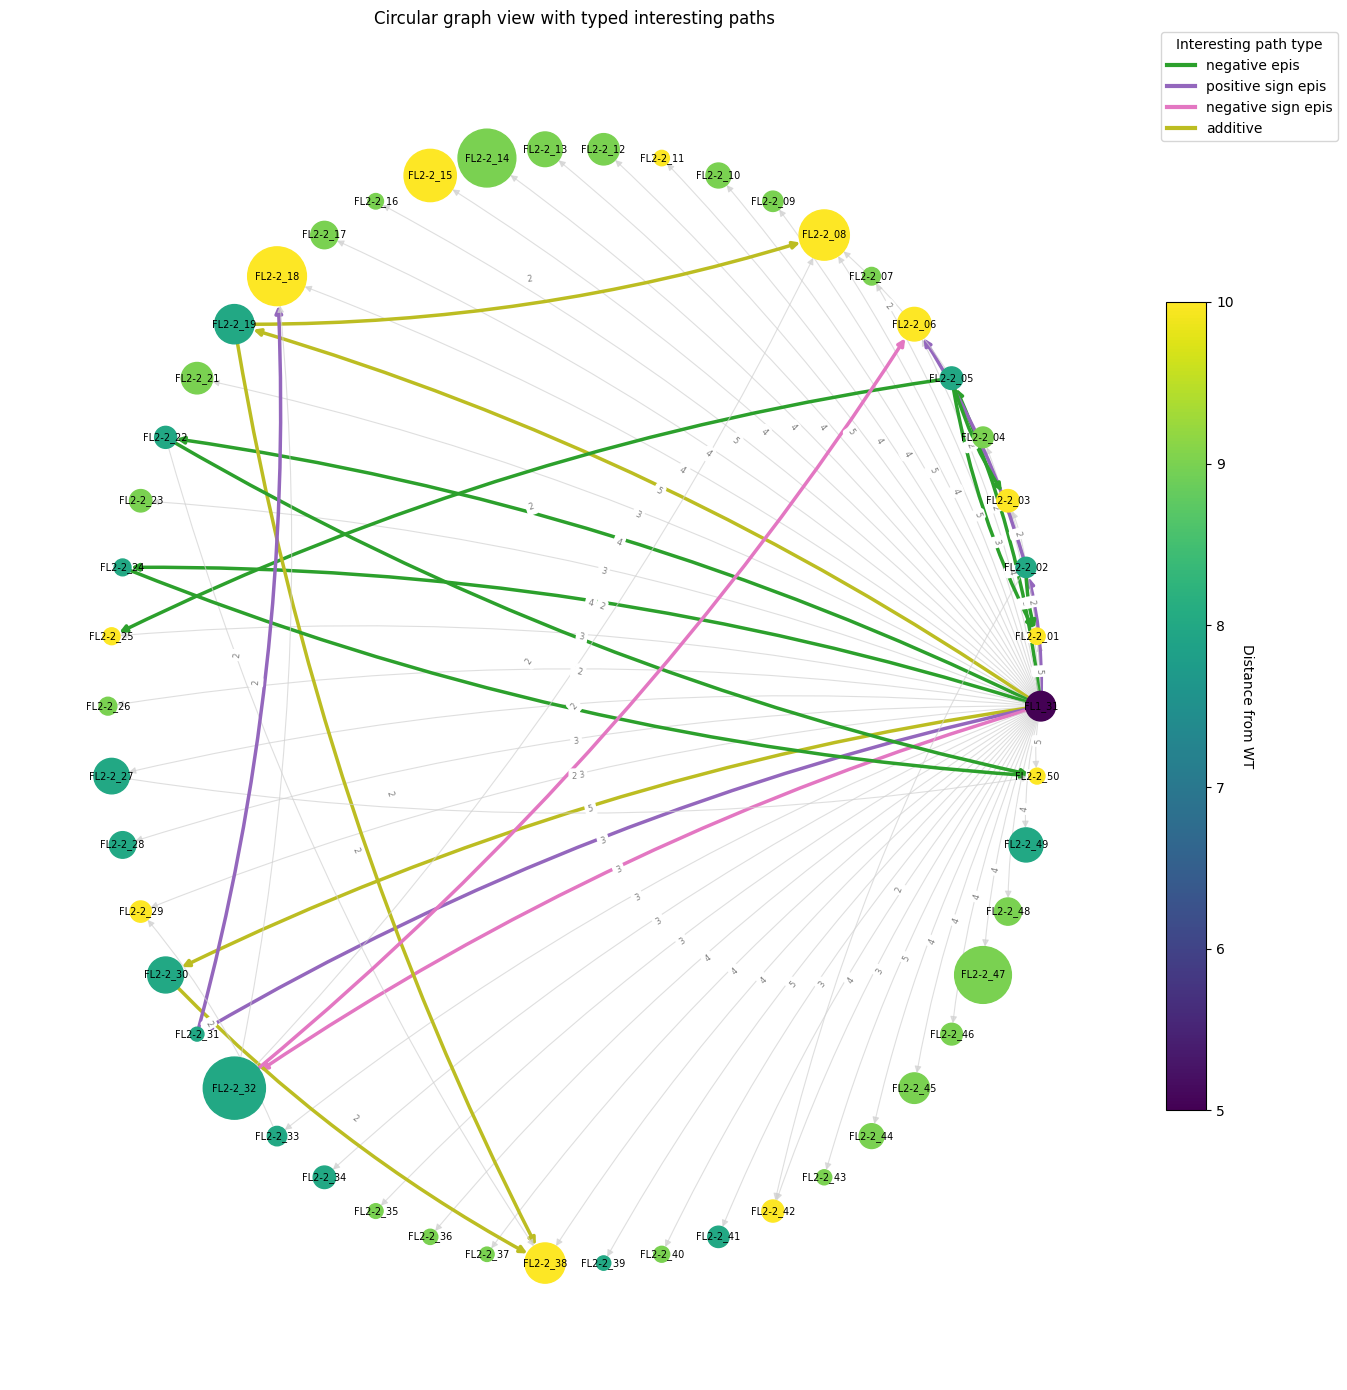

In [25]:
from matplotlib.lines import Line2D

# Circular matplotlib visualization
pos = nx.circular_layout(G)

dist_vals = np.array([G.nodes[n]['diff_from_WT'] for n in G.nodes()])
fold_vals = np.array([G.nodes[n]['fold_improvement'] for n in G.nodes()])

# Rebuild the discrete palette locally for a stable legend
type_cmap = plt.get_cmap("tab10", len(PathType))
path_type_colors = {path_type: type_cmap(index) for index, path_type in enumerate(PathType)}

# Color nodes by distance from WT using built-in Normalize + colormap
norm = plt.Normalize(vmin=dist_vals.min(), vmax=dist_vals.max())
node_colors = [cmap(norm(d)) for d in dist_vals]

# Size linearly scaled between 100 and 2000 by fold improvement
size_norm = plt.Normalize(vmin=fold_vals.min(), vmax=fold_vals.max())
node_sizes = 100 + size_norm(fold_vals) * 1900

edge_list = list(G.edges())
default_edge_color = (0.82, 0.82, 0.82, 0.7)
highlighted_edges = {edge for edge in edge_list if 'path_type' in G.edges[edge]}
edge_colors = [
    G.edges[edge].get('color', default_edge_color) if edge in highlighted_edges else default_edge_color
    for edge in edge_list
]
edge_widths = [2.5 if edge in highlighted_edges else 0.8 for edge in edge_list]
edge_labels = {edge: G.edges[edge]['diff'] for edge in edge_list}

fig, ax = plt.subplots(figsize=(14, 14))
nx.draw(
    G,
    pos,
    ax=ax,
    with_labels=True,
    node_color=node_colors,
    edge_color=edge_colors,
    edgelist=edge_list,
    width=edge_widths,
    node_size=node_sizes,
    font_size=7,
    arrows=True,
    arrowsize=10,
    connectionstyle='arc3,rad=0.08',
)

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='gray', font_size=6)

used_path_types = {G.edges[edge]['path_type'] for edge in highlighted_edges}
legend_handles = [
    Line2D([0], [0], color=path_type_colors[path_type], lw=3, label=path_type.value.replace('_', ' '))
    for path_type in PathType
    if path_type in used_path_types
]
if legend_handles:
    ax.legend(handles=legend_handles, title='Interesting path type',
              loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Distance from WT', rotation=270, labelpad=15)

ax.set_title('Circular graph view with typed interesting paths')
plt.tight_layout()
plt.show()

In [26]:
# for each interesting path, list the mutations added at each step
for path in interesting_paths:
    print(f"Path: {' -> '.join(path)}")
    for i in range(len(path) - 1):
        node1 = path[i]
        node2 = path[i + 1]
        designed_pos_1 = designed_positions_df.loc[sequences_df['design'] == node1].values[0]
        designed_pos_2 = designed_positions_df.loc[sequences_df['design'] == node2].values[0]
        mutations = [f"{pos}{aa2}" for pos, aa1, aa2 in zip(designed_positions_df.columns, designed_pos_1, designed_pos_2) if aa1 != aa2]
        print(f"  {node1} -> {node2}: Mutations: {mutations}, Fold Improvement: {G.nodes[node1]['fold_improvement']} -> {G.nodes[node2]['fold_improvement']}, Ratio: {G.nodes[node2]['fold_improvement'] / G.nodes[node1]['fold_improvement']:.2f}")
    print("\n---\n")

Path: FL1_31 -> FL2-2_05 -> FL2-2_08
  FL1_31 -> FL2-2_05: Mutations: ['I37W', 'Y176F', 'L252F'], Fold Improvement: 81.3 -> 38.4, Ratio: 0.47
  FL2-2_05 -> FL2-2_08: Mutations: ['N248D', 'F253Y'], Fold Improvement: 38.4 -> 275.0, Ratio: 7.16

---

Path: FL1_31 -> FL2-2_24 -> FL2-2_50
  FL1_31 -> FL2-2_24: Mutations: ['E34S', 'I37V', 'Y176F'], Fold Improvement: 81.3 -> 11.5, Ratio: 0.14
  FL2-2_24 -> FL2-2_50: Mutations: ['N248D', 'L252F'], Fold Improvement: 11.5 -> 8.1, Ratio: 0.70

---

Path: FL1_31 -> FL2-2_27 -> FL2-2_50
  FL1_31 -> FL2-2_27: Mutations: ['I37V', 'N248D', 'L252F'], Fold Improvement: 81.3 -> 126.0, Ratio: 1.55
  FL2-2_27 -> FL2-2_50: Mutations: ['E34S', 'Y176F'], Fold Improvement: 126.0 -> 8.1, Ratio: 0.06

---

Path: FL1_31 -> FL2-2_31 -> FL2-2_18
  FL1_31 -> FL2-2_31: Mutations: ['E34N', 'I37W', 'N248D'], Fold Improvement: 81.3 -> 1.0, Ratio: 0.01
  FL2-2_31 -> FL2-2_18: Mutations: ['L252M', 'F253Y'], Fold Improvement: 1.0 -> 384.3, Ratio: 384.30

---

Path: FL1_31 

In [27]:
def get_common_positions_and_mutations(paths, designed_positions_df, sequences_df):
    mutations_sets, positions_sets = [], []
    for path in paths:
        print(f"Path: {' -> '.join(path)}")
        positions_in_path = []
        mutations_in_path = []
        for i in range(len(path) - 1):
            node1 = path[i]
            node2 = path[i + 1]
            designed_pos_1 = designed_positions_df.loc[sequences_df['design'] == node1].values[0]
            designed_pos_2 = designed_positions_df.loc[sequences_df['design'] == node2].values[0]
            mutations = [f"{pos}{aa2}" for pos, aa1, aa2 in zip(designed_positions_df.columns, designed_pos_1, designed_pos_2) if aa1 != aa2]
            positions = [pos for pos, aa1, aa2 in zip(designed_positions_df.columns, designed_pos_1, designed_pos_2) if aa1 != aa2]
            positions_in_path.extend(positions)
            mutations_in_path.extend(mutations)
        mutations_sets.append(set(mutations_in_path))
        positions_sets.append(set(positions_in_path))
    
    common_positions = set.intersection(*positions_sets)
    common_mutations = set.intersection(*mutations_sets)
    return common_positions, common_mutations

In [28]:
get_common_positions_and_mutations(paths_dict[PathType.POSITIVE_SIGN_EPIS], designed_positions_df, sequences_df)

Path: FL1_31 -> FL2-2_02 -> FL2-2_06
Path: FL1_31 -> FL2-2_31 -> FL2-2_18


({'E34', 'F253', 'I37', 'L252', 'N248'}, {'F253Y', 'I37W', 'N248D'})

In [29]:
get_common_positions_and_mutations(paths_dict[PathType.ADDITIVE], designed_positions_df, sequences_df)

Path: FL1_31 -> FL2-2_19 -> FL2-2_08
Path: FL1_31 -> FL2-2_19 -> FL2-2_38
Path: FL1_31 -> FL2-2_30 -> FL2-2_38


({'F253', 'I37', 'L252', 'N248', 'Y176'}, {'F253Y', 'N248D', 'Y176F'})

In [30]:
get_common_positions_and_mutations(paths_dict[PathType.NEGATIVE_EPIS], designed_positions_df, sequences_df)

Path: FL1_31 -> FL2-2_02 -> FL2-2_01
Path: FL1_31 -> FL2-2_05 -> FL2-2_01
Path: FL1_31 -> FL2-2_05 -> FL2-2_03
Path: FL1_31 -> FL2-2_05 -> FL2-2_25
Path: FL1_31 -> FL2-2_22 -> FL2-2_50
Path: FL1_31 -> FL2-2_24 -> FL2-2_50


({'E34', 'I37', 'L252', 'Y176'}, {'L252F', 'Y176F'})